# Quantum Errors

In the previous chapters, quantum circuits are mostly treated as unitary maps on pure states. Real quantum devices are open systems: unwanted coupling to the environment, imperfect control pulses, and finite readout accuracy turn ideal unitary evolution into noisy quantum channels.

In this chapter we use density matrices to model noise, then introduce two basic strategies against noise: error mitigation for near-term devices and error correction for fault-tolerant quantum computation.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import tensorcircuit as tc
import numpy as np
from matplotlib import pyplot as plt

tc.set_dtype("complex128")
K = tc.set_backend("jax")

np.set_printoptions(precision=4, suppress=True)

## Quantum channels

A pure state $\vert\psi\rangle$ is represented by a density matrix $\rho=\vert\psi\rangle\langle\psi\vert$. More generally, mixed states are positive semidefinite matrices with $\mathrm{Tr}(\rho)=1$.

A physical noisy operation is a completely positive trace-preserving (CPTP) map, or quantum channel,

$$
\mathcal{E}(\rho)=\sum_k E_k\rho E_k^\dagger,
\qquad \sum_k E_k^\dagger E_k=I .
$$

The matrices $E_k$ are called Kraus operators. Different Kraus representations can describe the same channel, but the Choi matrix or the superoperator fixes the channel itself.

*Excercise:* Inspect several one-qubit noise channels in their Kraus representation and visualize their action on the Bloch vector.

phase damping
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
amplitude damping
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
depolarizing
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]


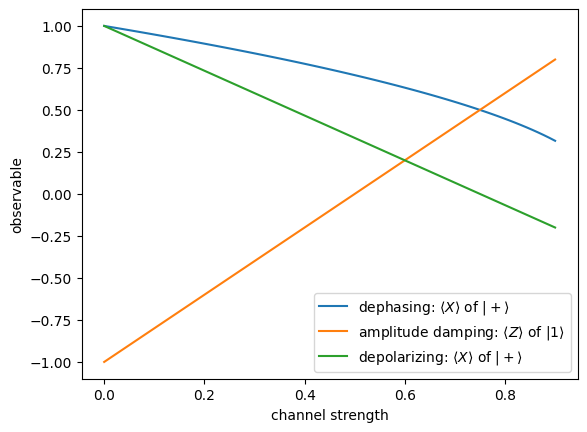

In [2]:
I2 = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
paulis = [X, Y, Z]


def gate_array(g):
    return np.asarray(g.tensor) if hasattr(g, "tensor") else np.asarray(g)


def apply_kraus(rho, kraus):
    return sum(gate_array(e) @ rho @ gate_array(e).conj().T for e in kraus)


def bloch_state(r):
    return (I2 + r[0] * X + r[1] * Y + r[2] * Z) / 2


def bloch_vector(rho):
    return np.real([np.trace(rho @ p) for p in paulis])


def kraus_identity(kraus):
    return sum(gate_array(e).conj().T @ gate_array(e) for e in kraus)


rho_plus = bloch_state([1, 0, 0])
rho_one = bloch_state([0, 0, -1])

gamma = 0.35
for name, kraus in [
    ("phase damping", tc.channels.phasedampingchannel(gamma)),
    ("amplitude damping", tc.channels.amplitudedampingchannel(gamma, 1.0)),
    ("depolarizing", tc.channels.depolarizingchannel(gamma / 3, gamma / 3, gamma / 3)),
]:
    print(name)
    print(kraus_identity(kraus))

gammas = np.linspace(0, 0.9, 80)
phase_x = []
amp_z = []
depol_x = []

for g in gammas:
    phase_x.append(
        bloch_vector(apply_kraus(rho_plus, tc.channels.phasedampingchannel(g)))[0]
    )
    amp_z.append(
        bloch_vector(apply_kraus(rho_one, tc.channels.amplitudedampingchannel(g, 1.0)))[
            2
        ]
    )
    rho_depol = apply_kraus(
        rho_plus, tc.channels.depolarizingchannel(g / 3, g / 3, g / 3)
    )
    depol_x.append(bloch_vector(rho_depol)[0])

plt.plot(gammas, phase_x, label=r"dephasing: $\langle X\rangle$ of $|+\rangle$")
plt.plot(gammas, amp_z, label=r"amplitude damping: $\langle Z\rangle$ of $|1\rangle$")
plt.plot(gammas, depol_x, label=r"depolarizing: $\langle X\rangle$ of $|+\rangle$")
plt.xlabel("channel strength")
plt.ylabel("observable")
plt.legend()
plt.show()

The same channel can be represented by its Choi matrix, superoperator, or Kraus operators. The Choi matrix is especially useful because complete positivity becomes the simple condition $J(\mathcal{E})\succeq 0$.

In [3]:
kraus = tc.channels.phasedampingchannel(0.35)
choi = np.asarray(tc.channels.kraus_to_choi(kraus))
superop = np.asarray(tc.channels.kraus_to_super(kraus))
recovered_kraus = tc.channels.choi_to_kraus(choi)

print("Choi matrix:")
print(choi)
print("Choi eigenvalues:", np.linalg.eigvalsh(choi))
print("superoperator shape:", superop.shape)
print("number of Kraus operators recovered from Choi:", len(recovered_kraus))

# For TensorCircuit's unnormalized Choi convention, tracing over the output leg gives I.
print("partial trace of Choi:")
print(np.trace(choi.reshape(2, 2, 2, 2), axis1=0, axis2=2))

Choi matrix:
[[1.    +0.j 0.    +0.j 0.    +0.j 0.8062+0.j]
 [0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j]
 [0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j]
 [0.8062+0.j 0.    +0.j 0.    +0.j 1.    +0.j]]
Choi eigenvalues: [0.     0.     0.1938 1.8062]
superoperator shape: (4, 4)
number of Kraus operators recovered from Choi: 2
partial trace of Choi:
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]


## Quantum noise

For a small number of qubits, density-matrix simulation directly applies noisy channels after gates. TensorCircuit's `DMCircuit` keeps the full density matrix and supports common channels such as depolarizing noise, amplitude damping, phase damping, reset, and thermal relaxation.

The price is that the density matrix has size $2^n\times 2^n$, so the memory cost is much larger than pure-state simulation.

*Excercise:* Prepare a Bell pair and check how gate depolarizing noise suppresses both the Bell fidelity and the stabilizer correlations $\langle XX\rangle$, $\langle ZZ\rangle$.

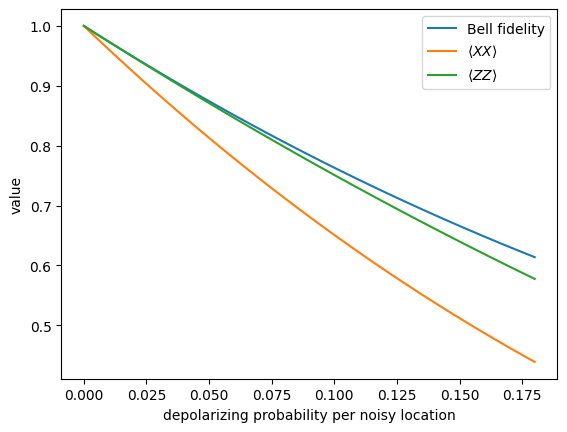

p = 0.03: fidelity, <XX>, <ZZ> = (0.9227679684149968, 0.8847359697167768, 0.9215999684549758)


In [4]:
bell = np.zeros(4, dtype=complex)
bell[0] = bell[3] = 1 / np.sqrt(2)


def noisy_bell(p):
    c = tc.DMCircuit(2)
    c.h(0)
    c.depolarizing(0, px=p / 3, py=p / 3, pz=p / 3)
    c.cnot(0, 1)
    c.depolarizing(0, px=p / 3, py=p / 3, pz=p / 3)
    c.depolarizing(1, px=p / 3, py=p / 3, pz=p / 3)
    rho = np.asarray(c.densitymatrix())
    fidelity = float(np.real(bell.conj() @ rho @ bell))
    xx = float(np.real(c.expectation_ps(x=[0, 1])))
    zz = float(np.real(c.expectation_ps(z=[0, 1])))
    return fidelity, xx, zz


ps = np.linspace(0, 0.18, 50)
results = np.array([noisy_bell(p) for p in ps])

plt.plot(ps, results[:, 0], label="Bell fidelity")
plt.plot(ps, results[:, 1], label=r"$\langle XX\rangle$")
plt.plot(ps, results[:, 2], label=r"$\langle ZZ\rangle$")
plt.xlabel("depolarizing probability per noisy location")
plt.ylabel("value")
plt.legend()
plt.show()

print("p = 0.03: fidelity, <XX>, <ZZ> =", noisy_bell(0.03))

Different physical mechanisms leave different signatures. $T_1$ relaxation moves population toward the ground state, while $T_2$ dephasing suppresses phase coherence. A Ramsey experiment is the simplest circuit-level diagnostic of dephasing.

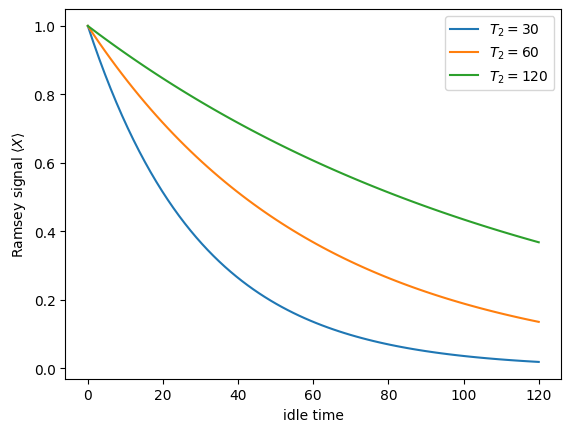

In [5]:
def ramsey_signal(t1, t2, time):
    c = tc.DMCircuit(1)
    c.h(0)
    c.thermalrelaxation(0, t1=t1, t2=t2, time=time, method="AUTO")
    return np.real(c.expectation_ps(x=[0]))


times = np.linspace(0, 120, 80)
for t2 in [30, 60, 120]:
    signal = [ramsey_signal(t1=200, t2=t2, time=t) for t in times]
    plt.plot(times, signal, label=rf"$T_2={t2}$")

plt.xlabel("idle time")
plt.ylabel(r"Ramsey signal $\langle X\rangle$")
plt.legend()
plt.show()

## Quantum error mitigation

Quantum error mitigation (QEM) aims to estimate ideal expectation values without encoding logical qubits. It does not remove errors from the quantum state; instead, it uses extra experiments and classical post-processing to reduce bias in observables.

TensorCircuit-NG also provides modular support for running circuits with or without error mitigation, including built-in zero-noise extrapolation (ZNE) and scalable readout error mitigation workflows. Here we use a simple toy implementation to expose the basic idea explicitly.

One common method is **zero-noise extrapolation (ZNE)**:

1. Estimate the same observable at several amplified noise levels $\lambda p$.
2. Fit the observable as a smooth function of $\lambda$.
3. Extrapolate the fit to $\lambda=0$.

*Excercise:* Apply zero-noise extrapolation to recover the ideal value $\langle XX\rangle=1$ for a noisy Bell-state circuit.

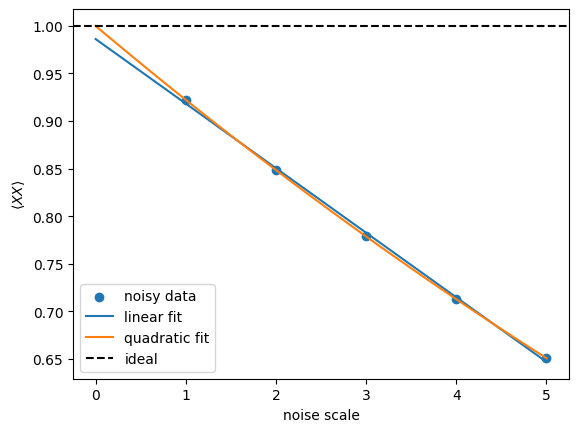

raw noisy estimate: 0.9221143388077396
ZNE linear estimate: 0.9859427218081727
ZNE quadratic estimate: 0.9996813880045846


In [6]:
def noisy_bell_xx(p):
    _, xx, _ = noisy_bell(p)
    return xx


base_p = 0.02
scales = np.array([1, 2, 3, 4, 5], dtype=float)
noisy_values = np.array([noisy_bell_xx(base_p * s) for s in scales])

linear_fit = np.polyfit(scales, noisy_values, deg=1)
quadratic_fit = np.polyfit(scales, noisy_values, deg=2)
zne_linear = np.polyval(linear_fit, 0.0)
zne_quadratic = np.polyval(quadratic_fit, 0.0)

fine_scales = np.linspace(0, scales[-1], 100)
plt.scatter(scales, noisy_values, label="noisy data")
plt.plot(fine_scales, np.polyval(linear_fit, fine_scales), label="linear fit")
plt.plot(fine_scales, np.polyval(quadratic_fit, fine_scales), label="quadratic fit")
plt.axhline(1.0, ls="--", color="k", label="ideal")
plt.xlabel("noise scale")
plt.ylabel(r"$\langle XX\rangle$")
plt.legend()
plt.show()

print("raw noisy estimate:", noisy_values[0])
print("ZNE linear estimate:", zne_linear)
print("ZNE quadratic estimate:", zne_quadratic)

A second simple QEM primitive is readout-error mitigation. If the classical assignment matrix $A_{y,x}=P(\text{read }y\mid\text{prepared }x)$ is calibrated, then the ideal probability vector can be estimated by solving $p_\mathrm{obs}=A p_\mathrm{ideal}$. The inversion can amplify sampling noise, so practical implementations often use constrained least squares or regularization.

In [7]:
# Single-qubit readout calibration example.
p0_to_1 = 0.04
p1_to_0 = 0.08
A = np.array([[1 - p0_to_1, p1_to_0], [p0_to_1, 1 - p1_to_0]])

true_probs = np.array([0.25, 0.75])
observed_probs = A @ true_probs
mitigated_probs = np.linalg.solve(A, observed_probs)

print("assignment matrix A:")
print(A)
print("observed probabilities:", observed_probs)
print("mitigated probabilities:", mitigated_probs)

assignment matrix A:
[[0.96 0.08]
 [0.04 0.92]]
observed probabilities: [0.3 0.7]
mitigated probabilities: [0.25 0.75]


## Quantum error correction

Quantum error correction (QEC) protects quantum information by encoding one logical qubit into many physical qubits and repeatedly extracting error syndromes. The syndrome reveals which error occurred without measuring the logical quantum information.

TensorCircuit-NG includes stabilizer-circuit functionality and detector-style sampling interfaces such as `sample_detector`, which are useful for larger error-correction simulations. The repetition-code example below is deliberately written as a small density-matrix toy model.

The three-qubit repetition code protects against a single bit-flip error:

$$
\vert 0_L\rangle=\vert 000\rangle,
\qquad
\vert 1_L\rangle=\vert 111\rangle.
$$

Its stabilizers are $Z_0Z_1$ and $Z_1Z_2$. Their measurement outcomes identify no error or a bit flip on one of the three physical qubits.

*Excercise:* Simulate the three-qubit repetition code as a quantum channel. Compare the unencoded physical bit-flip error rate with the logical error rate after ideal syndrome recovery.

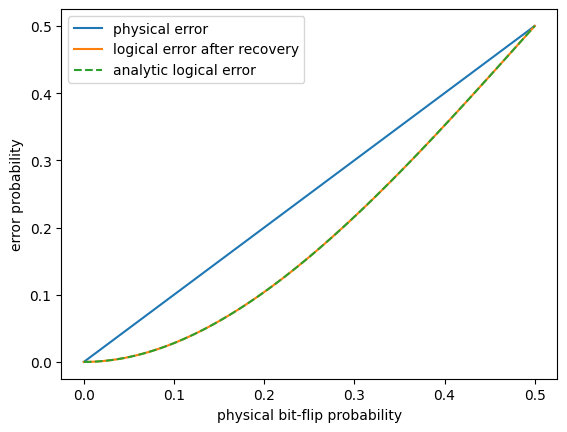

physical error at p=0.1: 0.1
logical error at p=0.1: 0.027999999999999803


In [8]:
def kron_all(ops):
    out = np.array([[1.0]], dtype=complex)
    for op in ops:
        out = np.kron(out, op)
    return out


def basis(bitstring):
    v = np.zeros(2 ** len(bitstring), dtype=complex)
    v[int(bitstring, 2)] = 1.0
    return v


def projector(bitstrings):
    return sum(np.outer(basis(s), basis(s).conj()) for s in bitstrings)


def bitflip_channel_n(rho, p, n=3):
    for q in range(n):
        xq = kron_all([X if i == q else I2 for i in range(n)])
        rho = (1 - p) * rho + p * xq @ rho @ xq
    return rho


def repetition_recovery(rho):
    # Syndrome subspaces for no error, X0, X1, and X2.
    syndrome_spaces = [
        (["000", "111"], I2),
        (["100", "011"], X),
        (["010", "101"], X),
        (["001", "110"], X),
    ]
    corrections = [
        kron_all([I2, I2, I2]),
        kron_all([X, I2, I2]),
        kron_all([I2, X, I2]),
        kron_all([I2, I2, X]),
    ]
    out = np.zeros_like(rho)
    for (strings, _), corr in zip(syndrome_spaces, corrections):
        p_s = projector(strings)
        out += corr @ p_s @ rho @ p_s @ corr.conj().T
    return out


zero = np.array([1, 0], dtype=complex)
zero_l = basis("000")
rho_zero = np.outer(zero, zero.conj())
rho_zero_l = np.outer(zero_l, zero_l.conj())

ps = np.linspace(0, 0.5, 100)
physical_success = []
logical_success = []
logical_success_formula = []

for p in ps:
    rho_phys = (1 - p) * rho_zero + p * X @ rho_zero @ X
    physical_success.append(np.real(zero.conj() @ rho_phys @ zero))

    noisy_encoded = bitflip_channel_n(rho_zero_l, p, n=3)
    recovered = repetition_recovery(noisy_encoded)
    logical_success.append(np.real(zero_l.conj() @ recovered @ zero_l))
    logical_success_formula.append((1 - p) ** 3 + 3 * p * (1 - p) ** 2)

plt.plot(ps, 1 - np.array(physical_success), label="physical error")
plt.plot(ps, 1 - np.array(logical_success), label="logical error after recovery")
plt.plot(
    ps, 1 - np.array(logical_success_formula), "--", label="analytic logical error"
)
plt.xlabel("physical bit-flip probability")
plt.ylabel("error probability")
plt.legend()
plt.show()

p = 0.1
print("physical error at p=0.1:", p)
print("logical error at p=0.1:", 1 - ((1 - p) ** 3 + 3 * p * (1 - p) ** 2))

The repetition code improves the error rate from $O(p)$ to $O(p^2)$ for small bit-flip probability $p$, because at least two physical bit flips are needed to cause a logical failure.

This code is not a complete quantum memory: it corrects bit flips but not arbitrary single-qubit errors. A full fault-tolerant architecture needs codes such as the Shor code, Steane code, surface code, or other stabilizer/topological codes that can correct both $X$ and $Z$ components of Pauli errors.

*Problem of this chapter:* Build the phase-flip repetition code by conjugating the above bit-flip code with Hadamard gates. Then compare three encodings under a depolarizing channel: no encoding, bit-flip repetition, and phase-flip repetition. Which Pauli component does each code suppress?